<a href="https://colab.research.google.com/github/marcosasilva4-dot/PAA/blob/main/projetovoto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando as bibliotecas

In [116]:
import pandas as pd
import numpy as np

from ipywidgets import interact
import seaborn as sns
import matplotlib.pyplot as plt

Carregar os dados de entrada

In [117]:
df_x = pd.read_csv('sample_data/planilha de voto.csv', sep=';')
display(df_x.head())

,"ARQUIVO,PEDIDO_VOTO,JUSTIFICATIVA",Unnamed: 1,Unnamed: 2
0,"17842900173358986.json,NAO,""[CoT]: 1. Tema pri...",NaN,NaN
1,"17846821800504032.json,NAO,""[CoT]: 1. Tema pri...",NaN,NaN
2,"17848212618549134.json,NAO,""[CoT]: 1. Tema pri...",NaN,NaN
3,"17853870882427439.json,NAO,""[CoT]: 1. Tema pri...",NaN,NaN
4,"17854035318338149.json,NAO,""[CoT]: 1. Tema pri...",NaN,NaN


In [118]:
# Extraia ARQUIVO, PEDIDO_VOTO e JUSTIFICATIVA usando regex
# Este padrão assume que os dados estão no formato: ARQUIVO,PEDIDO_VOTO,"JUSTIFICATIVA"
# Lida com aspas opcionais em torno de JUSTIFICATIVA e vários valores PEDIDO_VOTO.
regex_pattern = r'([^,]+),(NAO|SIM|OUTRO|[^,]+),"?(.*?)"?$'
# Aplicar a expressão regular à primeira (e provavelmente única) coluna de df_x
# Assumimos que os dados combinados estão na primeira coluna, cujo nome é 'ARQUIVO,PEDIDO_VOTO,JUSTIFICATIVA'
# Vamos renomeá-la temporariamente para 'combined_data' para maior clareza, caso ainda não esteja renomeada.

# Verificar se a coluna combinada existe e renomeá-la, se necessário, para manter a consistência do nome.
if 'ARQUIVO,PEDIDO_VOTO,JUSTIFICATIVA' in df_x.columns:
    df_x.rename(columns={'ARQUIVO,PEDIDO_VOTO,JUSTIFICATIVA': 'combined_data'}, inplace=True)
elif len(df_x.columns) == 1:
    df_x.columns = ['combined_data']
else:
    print("Warning: Expected a single combined column but found multiple. Parsing might fail.")

# Aplicar expressão regular para extrair componentes em novas colunas
extracted_data = df_x['combined_data'].str.extract(regex_pattern)

# Atribua nomes significativos às colunas extraídas
df_x['ARQUIVO'] = extracted_data[0]
df_x['PEDIDO_VOTO'] = extracted_data[1]
df_x['JUSTIFICATIVA'] = extracted_data[2]

# Elimine a coluna combinada original
df_x.drop(columns=['combined_data'], inplace=True)

display(df_x.head())

,Unnamed: 1,Unnamed: 2,ARQUIVO,PEDIDO_VOTO,JUSTIFICATIVA
0,NaN,NaN,17842900173358986.json,NAO,[CoT]: 1. Tema principal: discussão sobre um c...
1,NaN,NaN,17846821800504032.json,NAO,[CoT]: 1. Tema principal: elogio à disponibili...
2,NaN,NaN,17848212618549134.json,NAO,[CoT]: 1. Tema principal: Apresentação de um d...
3,NaN,NaN,17853870882427439.json,NAO,[CoT]: 1. Tema principal: Anúncio do programa ...
4,NaN,NaN,17854035318338149.json,NAO,[CoT]: 1. Tema principal: Entrega de equipamen...


In [119]:
# limpar 'JUSTIFICATIVA' coluna
if 'JUSTIFICATIVA' in df_x.columns:
    df_x['JUSTIFICATIVA'] = df_x['JUSTIFICATIVA'].str.strip('"').str.strip()

# limpa 'PEDIDO_VOTO' coluna
if 'PEDIDO_VOTO' in df_x.columns:
    df_x['PEDIDO_VOTO'] = df_x['PEDIDO_VOTO'].fillna('').str.upper().str.strip()
    df_x['PEDIDO_VOTO'] = df_x['PEDIDO_VOTO'].apply(lambda x: 'SIM' if 'SIM' in x else ('NAO' if 'NAO' in x else 'OUTRO'))
else:
    print("Warning: 'PEDIDO_VOTO' column not found. Cleaning cannot proceed as expected.")

# Exiba o DataFrame resultante para verificar a limpeza.
display(df_x.head())

,Unnamed: 1,Unnamed: 2,ARQUIVO,PEDIDO_VOTO,JUSTIFICATIVA
0,NaN,NaN,17842900173358986.json,NAO,[CoT]: 1. Tema principal: discussão sobre um c...
1,NaN,NaN,17846821800504032.json,NAO,[CoT]: 1. Tema principal: elogio à disponibili...
2,NaN,NaN,17848212618549134.json,NAO,[CoT]: 1. Tema principal: Apresentação de um d...
3,NaN,NaN,17853870882427439.json,NAO,[CoT]: 1. Tema principal: Anúncio do programa ...
4,NaN,NaN,17854035318338149.json,NAO,[CoT]: 1. Tema principal: Entrega de equipamen...


Distribuição de PEDIDO_VOTO após a limpeza:


,count
PEDIDO_VOTO,
NAO,89
SIM,19
OUTRO,3


/tmp/ipykernel_18011/3494091430.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=voto_counts.index, y=voto_counts.values, palette='viridis')


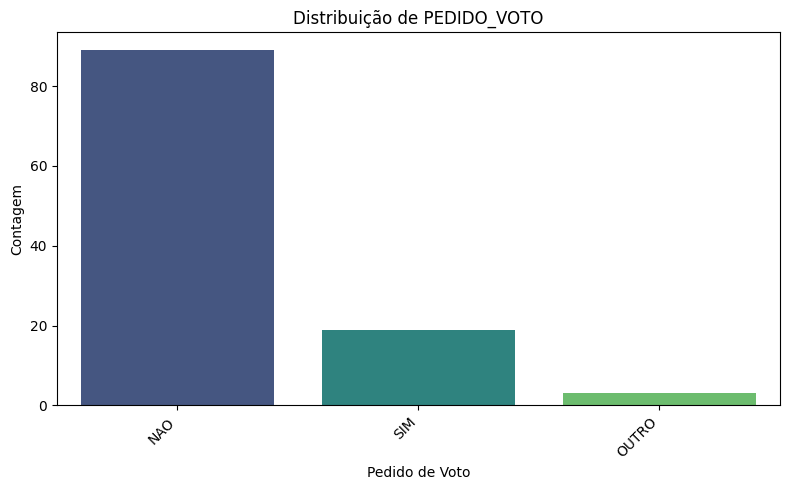

In [120]:
# Calcula a contagem de cada categoria em 'PEDIDO_VOTO'
voto_counts = df_x['PEDIDO_VOTO'].value_counts()

# Exibe a distribuição
print('Distribuição de PEDIDO_VOTO após a limpeza:')
display(voto_counts)

# Cria o gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(x=voto_counts.index, y=voto_counts.values, palette='viridis')
plt.title('Distribuição de PEDIDO_VOTO')
plt.xlabel('Pedido de Voto')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo x para melhor leitura
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

## Análise de Intenção de Voto Usando Aprendizado de Máquina


### 1. Pré-processamento do Texto


In [121]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Baixar recursos necessários do NLTK (se ainda não tiverem sido baixados)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

stop_words = set(stopwords.words('portuguese'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text): # Handle NaN values explicitly
        return ""
    text = str(text).lower() # Converter para string e minúsculas
    text = re.sub(r'[^a-z0-9áàãâéêíóôõúüç ]', '', text) # Remover pontuação e caracteres especiais (mantendo acentos)
    tokens = text.split() # Tokenização simples por espaço
    tokens = [word for word in tokens if word not in stop_words] # Remover stop words
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lematização
    return ' '.join(tokens)

# Aplicar o pré-processamento à coluna 'JUSTIFICATIVA'
df_x['JUSTIFICATIVA_CLEANED'] = df_x['JUSTIFICATIVA'].apply(preprocess_text)

display(df_x[['JUSTIFICATIVA', 'JUSTIFICATIVA_CLEANED']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,JUSTIFICATIVA,JUSTIFICATIVA_CLEANED
0,[CoT]: 1. Tema principal: discussão sobre um c...,cot 1 tema principal discussão sobre contrato ...
1,[CoT]: 1. Tema principal: elogio à disponibili...,cot 1 tema principal elogio disponibilidade ve...
2,[CoT]: 1. Tema principal: Apresentação de um d...,cot 1 tema principal apresentação desenho insp...
3,[CoT]: 1. Tema principal: Anúncio do programa ...,cot 1 tema principal anúncio programa próteses...
4,[CoT]: 1. Tema principal: Entrega de equipamen...,cot 1 tema principal entrega equipamentos assi...


### 2. Vetorização do Texto (TF-IDF)


In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inicializar o TF-IDF Vectorizer
# max_features pode ser ajustado para controlar o número de termos (palavras) no vocabulário
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limitando a 5000 características para começar

# Ajustar e transformar as justificativas limpas
X_tfidf = tfidf_vectorizer.fit_transform(df_x['JUSTIFICATIVA_CLEANED'])

print(f"Dimensões da matriz TF-IDF: {X_tfidf.shape}")
print("Alguns termos extraídos (primeiras 10 características):\n", tfidf_vectorizer.get_feature_names_out()[:10])

Dimensões da matriz TF-IDF: (111, 880)
Alguns termos extraídos (primeiras 10 características):
 ['100' '117' '12' '137' '19' '20128' '2024' '2025' '22' '2200']


### Próximos Passos para o Aprendizado de Máquina

Após o pré-processamento, os próximos passos seriam:

1.  **Vetorização**: Converter o texto limpo (`JUSTIFICATIVA_CLEANED`) em representações numéricas. Técnicas comuns incluem TF-IDF (Term Frequency-Inverse Document Frequency) ou Word Embeddings (e.g., Word2Vec, GloVe).
2.  **Rotulagem de Dados**: Para treinar um modelo de Machine Learning para identificar a intenção de voto para um `candidato específico`, você precisaria de um conjunto de dados rotulado, onde cada justificativa tenha uma indicação clara se ela expressa intenção de voto positiva, negativa ou neutra para aquele candidato. Este é um passo **crucial** e geralmente manual.
3.  **Divisão de Dados**: Separar seus dados rotulados em conjuntos de treinamento e teste.
4.  **Treinamento do Modelo**: Escolher e treinar um modelo de classificação (como Naive Bayes, SVM, Regressão Logística ou redes neurais) nos dados vetorizados e rotulados.
5.  **Avaliação do Modelo**: Avaliar a performance do modelo usando métricas apropriadas (precisão, recall, F1-score).


### 3. Preparação do Conjunto de Dados para Machine Learning

Agora que temos nossas justificativas vetorizadas (X_tfidf) e a intenção de voto (`PEDIDO_VOTO`), podemos preparar o conjunto de dados para treinar um modelo de Machine Learning.

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Definir a variável alvo (y)
y = df_x['PEDIDO_VOTO']

# Verificar a forma de X_tfidf e y
print(f"Shape of X_tfidf: {X_tfidf.shape}")
print(f"Shape of y: {y.shape}")

# Dividir os dados em conjuntos de treinamento e teste
# Usaremos 80% para treino e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Shape of X_tfidf: (111, 880)
Shape of y: (111,)
Tamanho do conjunto de treino: 88 amostras
Tamanho do conjunto de teste: 23 amostras


### 4. Treinamento e Avaliação do Modelo

Modelo de Regressão Logística, para problemas de classificação de texto.

In [124]:
# Inicializar e treinar o modelo de Regressão Logística
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o modelo
print("Acurácia do modelo:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

Acurácia do modelo: 0.8260869565217391

Relatório de Classificação:
               precision    recall  f1-score   support

         NAO       0.82      1.00      0.90        18
       OUTRO       0.00      0.00      0.00         1
         SIM       1.00      0.25      0.40         4

    accuracy                           0.83        23
   macro avg       0.61      0.42      0.43        23
weighted avg       0.81      0.83      0.77        23



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Resumo dos Resultados do Modelo

O modelo de Regressão Logística foi treinado e avaliado na tarefa de classificar o 'PEDIDO_VOTO' com base nas justificativas. Os resultados do `classification_report` fornecem métricas importantes como precisão (precision), recall, F1-score e suporte para cada classe ('NAO', 'OUTRO', 'SIM').

*   **Acurácia**: Indica a proporção de previsões corretas em relação ao total.
*   **Precision (Precisão)**: Para cada classe, é a proporção de verdadeiros positivos em relação a todos os exemplos classificados como aquela classe. Uma alta precisão significa menos falsos positivos.
*   **Recall (Revocação/Sensibilidade)**: Para cada classe, é a proporção de verdadeiros positivos em relação a todos os exemplos que realmente pertencem àquela classe. Um alto recall significa menos falsos negativos.
*   **F1-score**: É a média harmônica de precisão e recall, fornecendo um equilíbrio entre as duas métricas.
*   **Support (Suporte)**: O número de ocorrências reais da classe no conjunto de teste.


## Construindo um Dashboard: Análise de Palavras-Chave por Intenção de Voto

Para o nosso dashboard, vamos focar em insights do modelo de Machine Learning, especialmente as palavras-chave mais relevantes para cada tipo de intenção de voto ('NAO', 'OUTRO', 'SIM'). Isso nos ajudará a entender melhor o que impulsiona as classificações. Vamos visualizar os coeficientes do modelo de Regressão Logística para identificar essas palavras-chave.

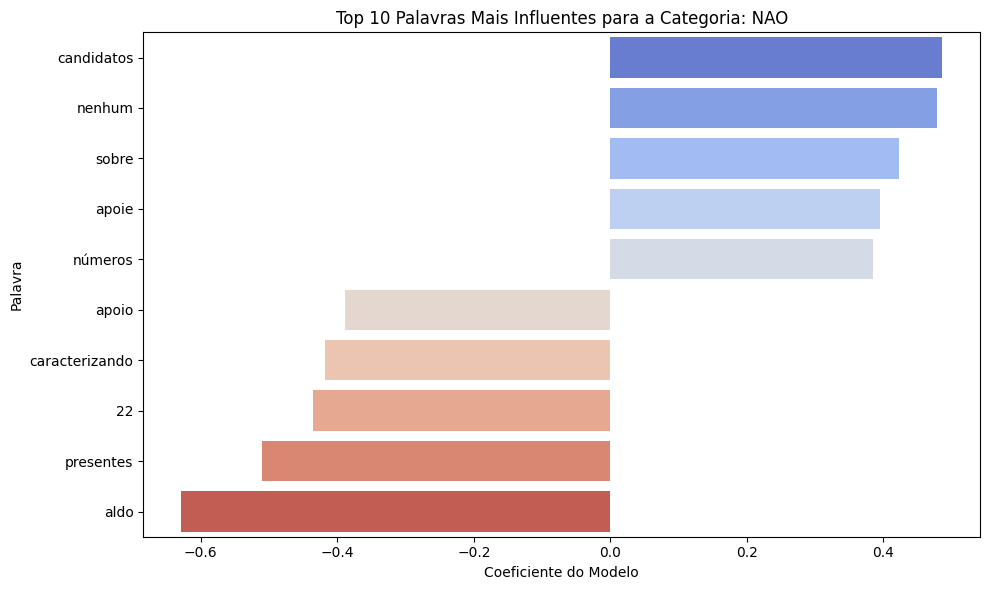

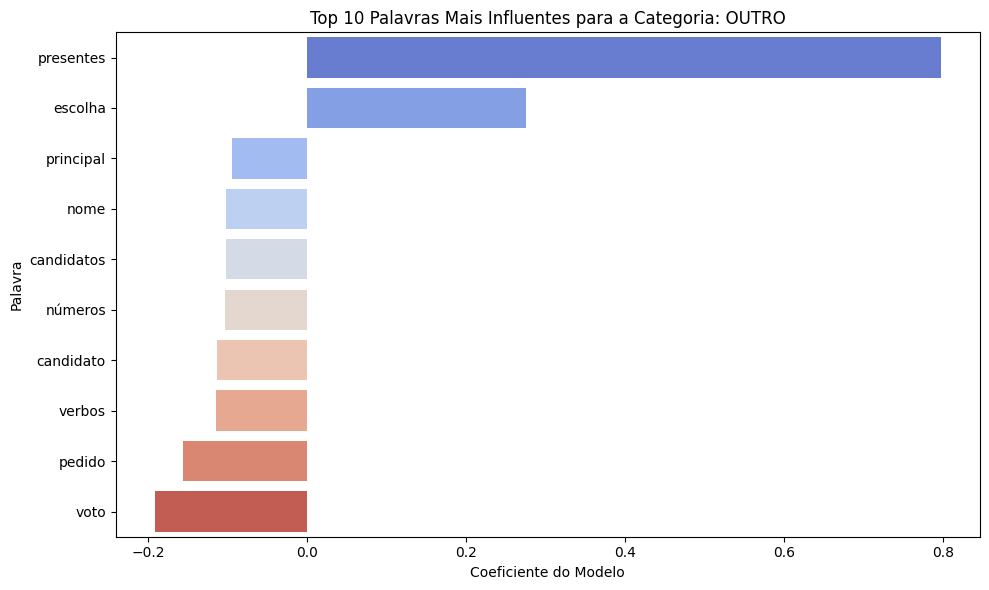

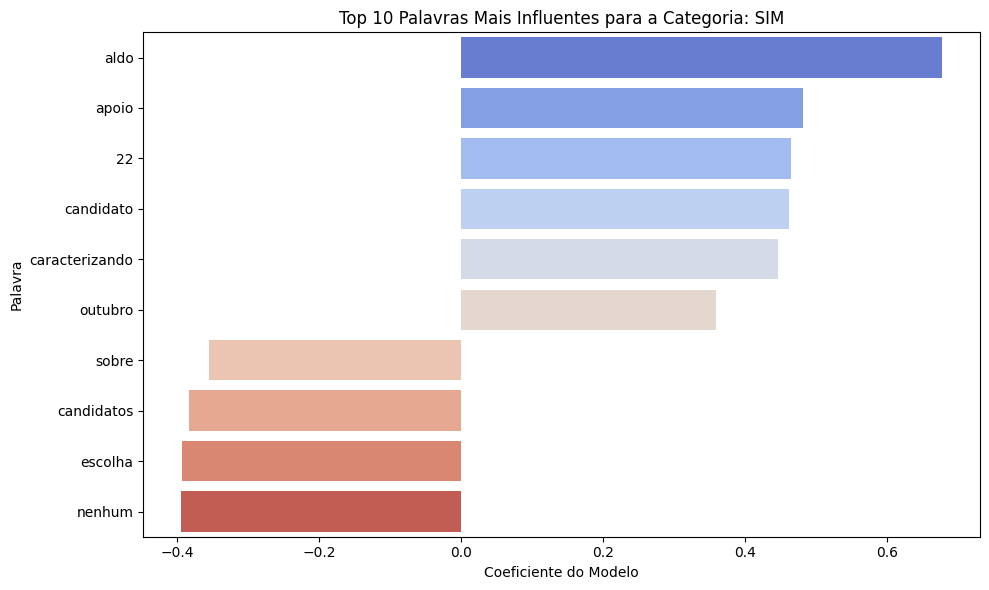

In [125]:
feature_names = tfidf_vectorizer.get_feature_names_out()

def plot_top_words_for_class(model, feature_names, class_id, class_name, top_n=10):
    # Obter os coeficientes para a classe específica
    # Para modelos multi-classe, model.coef_ tem uma linha por classe
    # Se for binário, terá apenas uma linha, e precisamos ajustar para ser como multi-classe
    if model.coef_.shape[0] == 1: # Binary case
        coefficients = model.coef_[0]
        if class_name == 'NAO':
# Assumindo que 'NAO' é a classe negativa e 'SIM' é a positiva.
# Para classificação binária, os coeficientes mostram diretamente a importância da classe positiva em relação à negativa.
# Para obter a importância de 'NAO', podemos considerar os coeficientes negativos da classe positiva.
# Esta parte pode precisar de ajustes dependendo de como o LogisticRegression lida com rótulos binários vs. multiclasse.
# Por enquanto, vamos assumir que class_id se refere ao índice em model.classes_
             idx = list(model.classes_).index(class_name)
             if idx == 0: # Se 'NAO' for a primeira classe (geralmente a negativa em classificações binárias)
                 coefs = -coefficients # Inverter para ver o que define como 'NAO'
             else:
                 coefs = coefficients # O que define como 'SIM'
        else:
             coefs = coefficients
    else:
        coefs = model.coef_[class_id]

    # Criar um DataFrame para facilitar a ordenação
    df_coefs = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    df_coefs['abs_coefficient'] = df_coefs['coefficient'].abs()

    # Ordenar por coeficientes absolutos para encontrar as palavras mais importantes
    df_coefs_sorted = df_coefs.sort_values(by='abs_coefficient', ascending=False)

    # Obter as top N palavras mais importantes
    top_words = df_coefs_sorted.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='coefficient', y='feature', data=top_words.sort_values(by='coefficient', ascending=False), palette='coolwarm', hue='feature', legend=False) # Fix: Added hue and legend=False
    plt.title(f'Top {top_n} Palavras Mais Influentes para a Categoria: {class_name}')
    plt.xlabel('Coeficiente do Modelo')
    plt.ylabel('Palavra')
    plt.tight_layout()
    plt.show()

# Mapear as classes do modelo para seus IDs
class_to_id = {cls_name: i for i, cls_name in enumerate(model.classes_)}

# Plotar para cada classe
for class_name in model.classes_:
    # Para classes com suporte muito baixo no conjunto de teste, pode ser menos significativo.
    # No entanto, os coeficientes são aprendidos no conjunto de treino.
    if class_name in class_to_id:
        plot_top_words_for_class(model, feature_names, class_to_id[class_name], class_name)

In [126]:
import pandas as pd

all_top_words_df = []
top_n_export = 20 # Define o número de palavras a exportar para cada classe

for class_name in model.classes_:
    class_id = class_to_id[class_name]

    # Obter os coeficientes para a classe específica, lidando com casos binários e multi-classe
    if model.coef_.shape[0] == 1: # Caso binário
        coefficients = model.coef_[0]
        if class_name == 'NAO':
            idx = list(model.classes_).index(class_name)
            if idx == 0:
                coefs = -coefficients # Inverter para ver o que define como 'NAO'
            else:
                coefs = coefficients
        else:
            coefs = coefficients
    else: # Caso multi-classe
        coefs = model.coef_[class_id]

    # Criar um DataFrame temporário para os coeficientes da classe atual
    df_coefs = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    df_coefs['abs_coefficient'] = df_coefs['coefficient'].abs()

    # Ordenar por coeficientes absolutos e pegar as top N
    df_coefs_sorted = df_coefs.sort_values(by='abs_coefficient', ascending=False)
    top_words = df_coefs_sorted.head(top_n_export).copy()

    # Adicionar a coluna de classe e armazenar
    top_words['class'] = class_name
    all_top_words_df.append(top_words)

# Concatenar todos os DataFrames em um único para exportação
final_export_df = pd.concat(all_top_words_df, ignore_index=True)

# Selecionar e reordenar colunas para maior clareza no CSV
final_export_df = final_export_df[['class', 'feature', 'coefficient', 'abs_coefficient']]

# Salvar o DataFrame em um arquivo CSV
output_filename = 'top_influential_words_by_vote_intention.csv'
final_export_df.to_csv(output_filename, index=False)

print(f"As palavras mais influentes foram exportadas para '{output_filename}'")
display(final_export_df.head())

As palavras mais influentes foram exportadas para 'top_influential_words_by_vote_intention.csv'


,class,feature,coefficient,abs_coefficient
0,NAO,aldo,-0.628468,0.628468
1,NAO,presentes,-0.510861,0.510861
2,NAO,candidatos,0.485751,0.485751
3,NAO,nenhum,0.478546,0.478546
4,NAO,22,-0.436069,0.436069


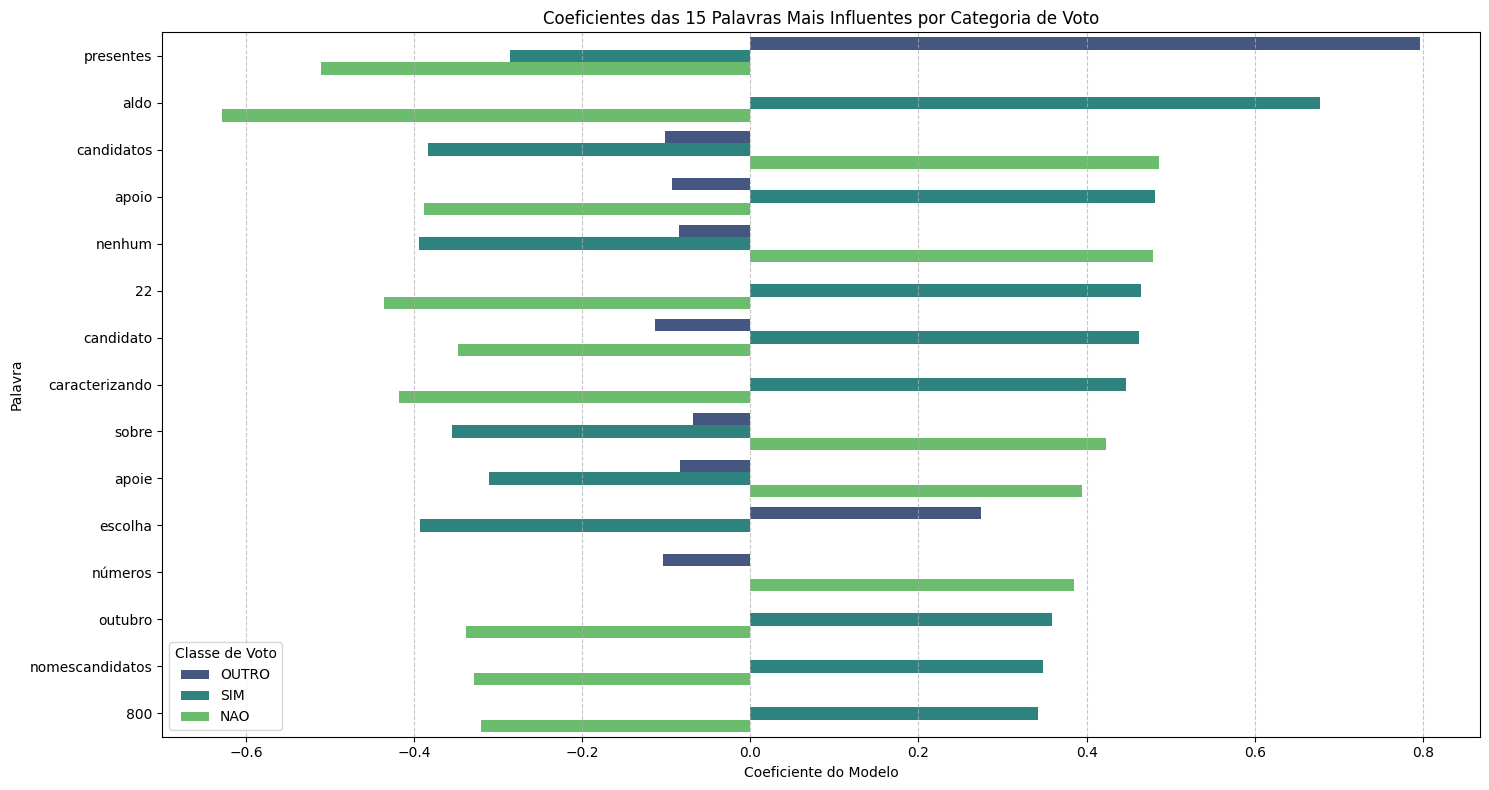

In [127]:
# Definir o número de palavras mais influentes para comparação
top_overall_features_count = 15

# Encontrar o coeficiente absoluto máximo para cada palavra em todas as classes
feature_max_abs_coef = final_export_df.groupby('feature')['abs_coefficient'].max().sort_values(ascending=False)

# Obter os nomes das N palavras mais influentes no geral
top_features_for_comparison = feature_max_abs_coef.head(top_overall_features_count).index.tolist()

# Filtrar o DataFrame para incluir apenas estas palavras
df_comparison = final_export_df[final_export_df['feature'].isin(top_features_for_comparison)].copy()

# Pivotar o DataFrame para que as classes se tornem colunas, preenchendo NaNs com 0 (caso uma palavra não apareça em alguma classe)
df_pivot = df_comparison.pivot_table(index='feature', columns='class', values='coefficient').fillna(0).reset_index()

# Despivotar (melt) o DataFrame para ter um formato adequado para o seaborn barplot agrupado
df_melted = df_pivot.melt(id_vars='feature', var_name='class', value_name='coefficient')

# Ordenar as features pela sua importância geral para uma melhor visualização
df_melted['feature'] = pd.Categorical(df_melted['feature'], categories=top_features_for_comparison, ordered=True)
df_melted = df_melted.sort_values(by='feature', ascending=False)

# Criar o gráfico de barras agrupado
plt.figure(figsize=(15, 8))
sns.barplot(data=df_melted, x='coefficient', y='feature', hue='class', palette='viridis')
plt.title(f'Coeficientes das {top_overall_features_count} Palavras Mais Influentes por Categoria de Voto')
plt.xlabel('Coeficiente do Modelo')
plt.ylabel('Palavra')
plt.legend(title='Classe de Voto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()